In [1]:
# ============================
# CELL 1: COMMON DEFINITIONS
# Plain MLP + RAD + RAR-G + Causal (Wang et al. 2022)
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from google.colab import drive
drive.mount('/content/drive')

# ===========================
# Reproducibility
# ===========================
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ==========================
# Device
# ==========================
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
print('using device:', device)

# ===========================
# PINN MODEL
# ===========================
LAYERS  = 8
NEURONS = 256
N_FOURIER        = 0
B_SCALE          = 0

class PINN(nn.Module):
    def __init__(self, layers=LAYERS, neurons=NEURONS):
        super().__init__()
        net = [nn.Linear(3, neurons), nn.Tanh()]
        for _ in range(layers - 1):
            net += [nn.Linear(neurons, neurons), nn.Tanh()]
        net += [nn.Linear(neurons, 1)]
        self.net = nn.Sequential(*net)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

model = PINN().to(device)

# ===========================
# Hyperparameters
# ===========================
N_f          = 10000
N_i          = 5000
T_final      = 2 * np.pi
adam_epochs  = 20000
lbfgs_epochs = 500

w_pde      = 1.0
w_ic       = 10.0
w_eik      = 0.0
# =========================
# Wang et al. 2022 Causal Settings
# =========================
M_CHUNKS   = 10
EPS_CAUSAL = 1.0

# =========================
# RAD Settings
# =========================
RAD_FREQ       = 1000
RAD_CANDIDATES = 20000
RAD_K          = 1.0
RAD_C          = 1.0

# =========================
# RAR-G Settings
# =========================
RAR_FREQ       = 1800
RAR_CANDIDATES = 50000
RAR_ADD        = 500

# =========================
# Velocity Field — CHANGED: rigid body rotation (Mullins Eq. 41)
# u = (2π/T)(0.5 - y),  v = (2π/T)(x - 0.5)
# Time-independent: does not depend on t
# =========================
def velocity_field(x, y, t):
    omega = 2 * np.pi / T_final    # = 1.0 since T_final = 2π
    u = omega * (0.5 - y)
    v = omega * (x - 0.5)
    return u, v

# =========================
# Initial Condition — CHANGED: Zalesak disk SDF (Mullins geometry)
# =========================
def initial_condition(x, y):
    # ---- Circle SDF ----
    xc, yc, R = 0.5, 0.75, 0.15
    phi_circle = torch.sqrt((x - xc)**2 + (y - yc)**2) - R

    # ---- Slot rectangle SDF ----
    # Slot center (sx, sy), half-extents (hw, hh)
    sx, sy = 0.5, 0.725      # center of slot rectangle
    hw, hh = 0.025, 0.125    # half-width, half-height

    dx = torch.abs(x - sx) - hw
    dy = torch.abs(y - sy) - hh

    # Standard box SDF formula
    # Outside: sqrt(max(dx,0)² + max(dy,0)²)
    # Inside:  min(max(dx,dy), 0)
    phi_slot = (torch.sqrt(torch.clamp(dx, min=0)**2 +
                           torch.clamp(dy, min=0)**2) +
                torch.clamp(torch.maximum(dx, dy), max=0))

    # ---- Slotted disk: circle minus slot ----
    return torch.maximum(phi_circle, -phi_slot)
# =========================
# Sample Points
# =========================
torch.manual_seed(100)
torch.cuda.manual_seed(100)

X_f_base = torch.rand(N_f, 3, dtype=torch.float32, device=device).requires_grad_(True)

x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i = torch.cat([x_i, y_i, t_i], dim=1)

# =========================
# Residual Helper
# =========================
def compute_residuals(X_cand):
    X_c   = X_cand.detach().requires_grad_(True)
    phi   = model(X_c)
    grads = torch.autograd.grad(phi, X_c,
                                grad_outputs=torch.ones_like(phi),
                                create_graph=False)[0]
    phi_x = grads[:, 0:1]
    phi_y = grads[:, 1:2]
    phi_t = grads[:, 2:3]
    u, v  = velocity_field(X_c[:, 0:1], X_c[:, 1:2], X_c[:, 2:3])
    res   = (phi_t + T_final * (u * phi_x + v * phi_y)).detach().abs().squeeze()
    return res

# =========================
# RAD
# =========================
def resample_rad():
    X_cand  = torch.rand(RAD_CANDIDATES, 3, dtype=torch.float32, device=device)
    res     = compute_residuals(X_cand)
    res_k   = res ** RAD_K
    E_res_k = res_k.mean() + 1e-8
    weights = res_k / E_res_k + RAD_C
    probs   = weights / weights.sum()
    idx     = torch.multinomial(probs, N_f, replacement=False)
    return X_cand[idx].detach().requires_grad_(True)

# =========================
# RAR-G
# =========================
def refine_rar(X_f_rar):
    X_cand  = torch.rand(RAR_CANDIDATES, 3, dtype=torch.float32, device=device)
    res     = compute_residuals(X_cand)
    _, idx  = torch.topk(res, RAR_ADD)
    new_pts = X_cand[idx].detach()
    if X_f_rar is None:
        X_f_rar = new_pts
    else:
        X_f_rar = torch.cat([X_f_rar, new_pts], dim=0)
    return X_f_rar.detach()

# =========================
# Loss Function
# =========================
def physics_loss(X_f_base, X_f_rar, X_i):

    if X_f_rar is not None and X_f_rar.shape[0] > 0:
        X_f_rar_grad = X_f_rar.detach().requires_grad_(True)
        X_f = torch.cat([X_f_base, X_f_rar_grad], dim=0)
    else:
        X_f = X_f_base

    phi      = model(X_f)
    grad_phi = torch.autograd.grad(phi, X_f,
                                   grad_outputs=torch.ones_like(phi),
                                   create_graph=True)[0]
    phi_x, phi_y, phi_t = grad_phi[:, 0:1], grad_phi[:, 1:2], grad_phi[:, 2:3]
    u, v      = velocity_field(X_f[:, 0:1], X_f[:, 1:2], X_f[:, 2:3])
    residuals = (phi_t + T_final * (u * phi_x + v * phi_y))**2

    N_total    = X_f.shape[0]
    CHUNK_SIZE = N_total // M_CHUNKS

    sorted_idx = torch.argsort(X_f[:, 2].detach())
    res_sorted = residuals[sorted_idx]

    chunk_losses = [
        torch.mean(res_sorted[m*CHUNK_SIZE:(m+1)*CHUNK_SIZE]).detach()
        for m in range(M_CHUNKS)
    ]

    cumsum = torch.tensor(0.0, device=device)
    w = []
    for m in range(M_CHUNKS):
        w.append(torch.exp(-EPS_CAUSAL * cumsum))
        cumsum = cumsum + chunk_losses[m]

    loss_pde = sum(
        w[m] * torch.mean(res_sorted[m*CHUNK_SIZE:(m+1)*CHUNK_SIZE])
        for m in range(M_CHUNKS)
    ) / M_CHUNKS

    phi_true = initial_condition(X_i[:, 0:1], X_i[:, 1:2])
    phi_pred = model(X_i)
    loss_ic  = torch.mean((phi_true - phi_pred)**2)

    norm_phi = torch.sqrt(phi_x**2 + phi_y**2 + 1e-8)
    loss_eik = torch.mean((norm_phi - 1.0)**2)

    total_loss = w_pde * loss_pde + w_ic * loss_ic + w_eik * loss_eik
    return loss_pde, loss_ic, loss_eik, total_loss

Mounted at /content/drive
Tesla T4
using device: cuda


In [2]:
# ============================
# CELL 2: TRAINING
# ============================
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_adam, T_max=adam_epochs, eta_min=1e-5)
start_time = time.time()
history = {'epoch': [], 'total': [], 'pde': [], 'ic': [], 'eik': [], 'X_f_total': []}

X_f_rar = None

for epoch in range(adam_epochs):

    if epoch > 0 and epoch % RAD_FREQ == 0:
        X_f_base = resample_rad()

    if epoch > 0 and epoch % RAR_FREQ == 0:
        X_f_rar = refine_rar(X_f_rar)

    optimizer_adam.zero_grad()
    loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f_base, X_f_rar, X_i)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_adam.step()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    rar_pts   = X_f_rar.shape[0] if X_f_rar is not None else 0
    total_pts = N_f + rar_pts

    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['eik'].append(loss_eik.item())
    history['X_f_total'].append(total_pts)

    if epoch % 2000 == 0:
        print(f"Adam {epoch:5d} | total {loss.item():.3e} | pde {loss_pde.item():.3e} | ic {loss_ic.item():.3e} | eik {loss_eik.item():.3e} | LR {lr:.3e} | base {N_f} + RAR {rar_pts}")
    elif epoch == adam_epochs - 1:
        print(f"Adam {adam_epochs:5d} | total {loss.item():.3e} | pde {loss_pde.item():.3e} | ic {loss_ic.item():.3e} | eik {loss_eik.item():.3e} | LR {lr:.3e} | base {N_f} + RAR {rar_pts}")

print("LBFGS Optimizer Starting...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0,
                               history_size=200,
                               line_search_fn='strong_wolfe')
loss_store = {}

for epoch in range(lbfgs_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f_base, X_f_rar, X_i)
        loss.backward()
        loss_store['total'] = loss.item()
        loss_store['pde']   = loss_pde.item()
        loss_store['ic']    = loss_ic.item()
        loss_store['eik']   = loss_eik.item()
        return loss
    optimizer_lbfgs.step(closure)

    history['epoch'].append(adam_epochs + epoch)
    history['total'].append(loss_store['total'])
    history['pde'].append(loss_store['pde'])
    history['ic'].append(loss_store['ic'])
    history['eik'].append(loss_store['eik'])
    history['X_f_total'].append(total_pts)

    if epoch % 200 == 0:
        print(f"LBFGS {epoch:4d} | total {loss_store['total']:.3e} | pde {loss_store['pde']:.3e} | ic {loss_store['ic']:.3e} | eik {loss_store['eik']:.3e}")
    elif epoch == lbfgs_epochs - 1:
        print(f"LBFGS {lbfgs_epochs:4d} | total {loss_store['total']:.3e} | pde {loss_store['pde']:.3e} | ic {loss_store['ic']:.3e} | eik {loss_store['eik']:.3e}")

end_time = time.time()
total_training_time = (end_time - start_time) / 60
print(f"Full training done in {total_training_time:.1f} minutes")
print(f"Final: base {N_f} + RAR {X_f_rar.shape[0] if X_f_rar is not None else 0} = {total_pts} points")

checkpoint_path = '/content/drive/MyDrive/ZD_S4_exp01.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_adam_state_dict': optimizer_adam.state_dict(),
    'optimizer_lbfgs_state_dict': optimizer_lbfgs.state_dict(),
    'training_time': f'{total_training_time:.1f} minutes',
    'history': history
}, checkpoint_path)
print(f"Saved to {checkpoint_path}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam     0 | total 2.968e+00 | pde 1.194e-01 | ic 2.849e-01 | eik 4.251e-01 | LR 1.000e-03 | base 10000 + RAR 0
Adam  2000 | total 1.814e-02 | pde 1.277e-02 | ic 5.368e-04 | eik 1.350e-01 | LR 9.757e-04 | base 10000 + RAR 500
Adam  4000 | total 8.376e-03 | pde 5.754e-03 | ic 2.621e-04 | eik 9.980e-02 | LR 9.054e-04 | base 10000 + RAR 1000
Adam  6000 | total 3.595e-03 | pde 2.306e-03 | ic 1.289e-04 | eik 5.785e-02 | LR 7.959e-04 | base 10000 + RAR 1500
Adam  8000 | total 8.852e-04 | pde 3.208e-04 | ic 5.644e-05 | eik 5.345e-02 | LR 6.579e-04 | base 10000 + RAR 2000
Adam 10000 | total 7.799e-04 | pde 2.452e-04 | ic 5.347e-05 | eik 4.236e-02 | LR 5.049e-04 | base 10000 + RAR 2500
Adam 12000 | total 6.180e-04 | pde 8.898e-05 | ic 5.291e-05 | eik 3.739e-02 | LR 3.520e-04 | base 10000 + RAR 3000
Adam 14000 | total 6.277e-04 | pde 9.600e-05 | ic 5.317e-05 | eik 2.949e-02 | LR 2.140e-04 | base 10000 + RAR 3500
Adam 16000 | total 5.723e-04 | pde 5.235e-05 | ic 5.200e-05 | eik 2.824e-02 | LR 1.0

In [2]:
# ===========================
# Load Model
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/ZD_S4_exp01.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


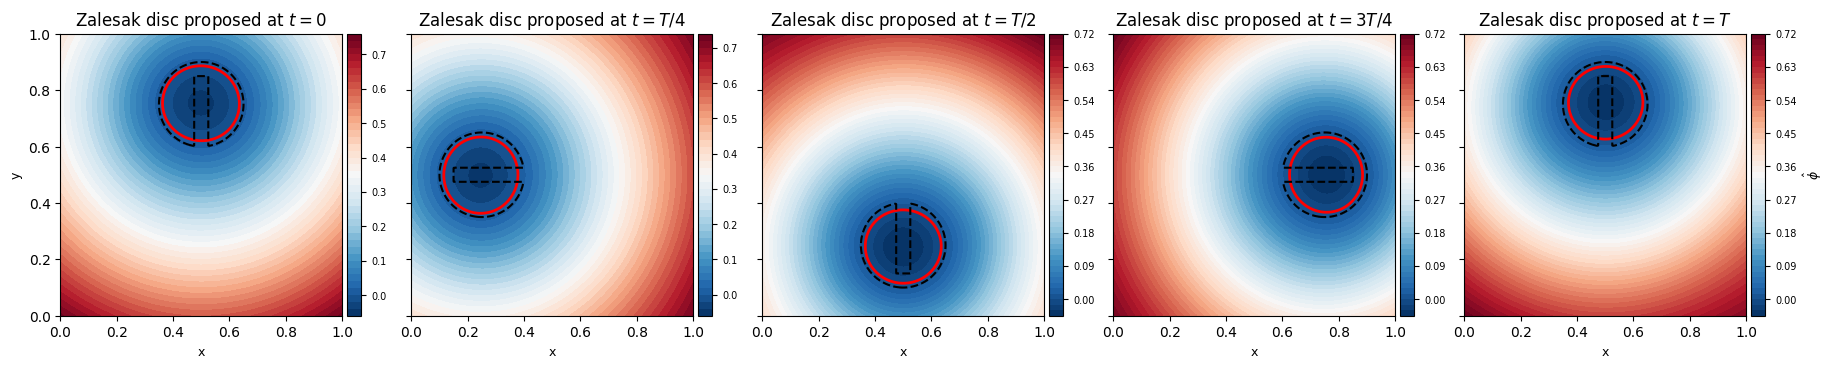

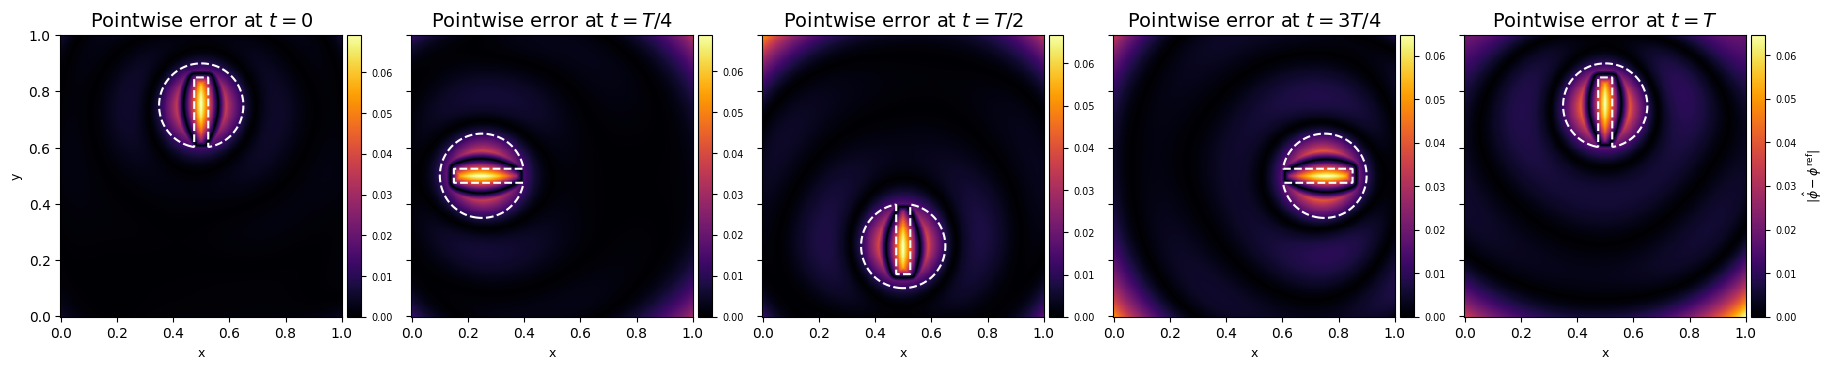


Snapshot           abs L2   rel L2 (%)     mass abs     MAPE (%)
--------------------------------------------------------------
t=0.00          7.18e-03        2.06%      2.18e-03        3.69%
t=1.57          7.90e-03        2.27%      3.09e-03        5.23%
t=3.14          8.50e-03        2.44%      4.03e-03        6.82%
t=4.71          8.69e-03        2.50%      4.89e-03        8.28%
t=6.28          9.71e-03        2.79%      5.58e-03        9.45%
--------------------------------------------------------------
avg              8.40e-03        2.41%      3.95e-03        6.70%


In [3]:
# ==============================================================
# CELL 4: VISUALIZATION
# Figure 1: phi field (1 row x 5 cols, per-snapshot colorbar)
# Figure 2: error field (1 row x 5 cols, per-snapshot colorbar)
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch

times = [0.0, T_final/4, T_final/2, 3*T_final/4, T_final]
nx = 300

x_1d = np.linspace(0, 1, nx)
y_1d = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x_1d, y_1d)
dx = dy = x_1d[1] - x_1d[0]

# ---- Geometry (Mullins et al. 2025) ----
XC, YC       = 0.5, 0.75    # disk center at t=0
R            = 0.15          # disk radius
W            = 0.025         # slot half-width  (w=0.05)
L            = 0.125         # slot half-height (h=0.25)
SLOT_YCENTER = 0.725         # slot center

# ---- Analytical reference (matches training IC exactly) ----
def exact_phi_rotated(X, Y, t):
    theta         = 2 * np.pi * t / T_final
    cos_t, sin_t  = np.cos(theta), np.sin(theta)

    # Rotate disk center around (0.5, 0.5)
    x0, y0  = 0.5, 0.5
    dx_c    = XC - x0;  dy_c = YC - y0
    XC_t    = x0 + cos_t*dx_c - sin_t*dy_c
    YC_t    = y0 + sin_t*dx_c + cos_t*dy_c

    # Global displacement from rotated disk center
    dX = X - XC_t
    dY = Y - YC_t

    # Local frame (rotate back)
    X_loc =  cos_t*dX + sin_t*dY
    Y_loc = -sin_t*dX + cos_t*dY

    # Circle SDF
    phi_circle = np.sqrt(dX**2 + dY**2) - R

    # Slot SDF — FIX 2: use proper box SDF to match training IC formula
    # (was: np.maximum(slot_x, slot_y) — sharp corners, mismatched training)
    slot_x  = np.abs(X_loc) - W
    slot_y  = np.abs(Y_loc - (SLOT_YCENTER - YC)) - L   # local offset = -0.125
    slot_xc = np.maximum(slot_x, 0.0)
    slot_yc = np.maximum(slot_y, 0.0)
    phi_slot = (np.sqrt(slot_xc**2 + slot_yc**2) +
                np.minimum(np.maximum(slot_x, slot_y), 0.0))

    return np.maximum(phi_circle, -phi_slot)

# ---- Collect predictions and references ----
phi_preds, phi_refs = [], []
l2_abs_list, l2_rel_list, mass_abs_list, mass_ape_list = [], [], [], []

phi_0   = exact_phi_rotated(X, Y, 0.0)
A_exact = np.sum(phi_0 < 0) * dx * dy    # reference area (correct geometry)

for t_val in times:
    t_norm = t_val / T_final
    XYT = torch.tensor(
        np.stack([X.flatten(), Y.flatten(),
                  t_norm * np.ones(X.size)], axis=1),
        dtype=torch.float32, device=device)
    with torch.no_grad():
        phi_pred = model(XYT).cpu().numpy().reshape(nx, nx)
    phi_ref = exact_phi_rotated(X, Y, t_val)
    phi_preds.append(phi_pred)
    phi_refs.append(phi_ref)

    l2_abs   = np.sqrt(np.mean((phi_pred - phi_ref)**2))
    l2_rel   = np.sqrt(np.sum((phi_pred - phi_ref)**2)) / np.sqrt(np.sum(phi_ref**2)) * 100
    A_pred   = np.sum(phi_pred < 0) * dx * dy
    mass_abs = abs(A_pred - A_exact)
    mass_ape = abs(A_pred - A_exact) / A_exact * 100

    l2_abs_list.append(l2_abs)
    l2_rel_list.append(l2_rel)
    mass_abs_list.append(mass_abs)
    mass_ape_list.append(mass_ape)

errors   = [np.abs(phi_preds[i] - phi_refs[i]) for i in range(5)]
tlabels  = ['t=0', 't=T/4', 't=T/2', 't=3T/4', 't=T']

from mpl_toolkits.axes_grid1 import ImageGrid

# ══════════════════════════════════════════════════════
# Figure 1: Predicted φ field
# ══════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(22, 5))
grid1 = ImageGrid(fig1, 111, nrows_ncols=(1, 5), axes_pad=0.5,
                  cbar_mode='each', cbar_location='right',
                  cbar_pad=0.05, cbar_size='5%')

for i, ax in enumerate(grid1):
    im = ax.contourf(X, Y, phi_preds[i], levels=50, cmap='RdBu_r')
    ax.contour(X, Y, phi_preds[i], levels=[0], colors='red',   linewidths=2)
    ax.contour(X, Y, phi_refs[i],  levels=[0], colors='black', linewidths=1.5,
               linestyles='--')
    ax.set_title(f'Zalesak disc proposed at ${tlabels[i]}$', fontsize=12)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9)
    if i == 0: ax.set_ylabel('y', fontsize=9)
    cb = grid1.cbar_axes[i].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    if i == 4: cb.set_label(r'$\hat{\phi}$', fontsize=9)
#plt.savefig('/content/drive/MyDrive/fig_ZD_S4_exp01_phi.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ══════════════════════════════════════════════════════
# Figure 2: Pointwise error
# ══════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(22, 5))
grid2 = ImageGrid(fig2, 111, nrows_ncols=(1, 5), axes_pad=0.5,
                  cbar_mode='each', cbar_location='right',
                  cbar_pad=0.05, cbar_size='5%')

for i, ax in enumerate(grid2):
    im = ax.pcolormesh(X, Y, errors[i], cmap='inferno',
                       vmin=0, vmax=errors[i].max(), shading='auto')
    ax.contour(X, Y, phi_refs[i], levels=[0], colors='white', linewidths=1.5,
               linestyles='--')
    ax.set_title(f'Pointwise error at ${tlabels[i]}$', fontsize=14)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9)
    if i == 0: ax.set_ylabel('y', fontsize=9)
    cb = grid2.cbar_axes[i].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    if i == 4: cb.set_label(r'$|\hat{\phi}-\phi^{\rm ref}|$', fontsize=9)
#plt.savefig('/content/drive/MyDrive/fig_ZD_S4_exp01_errors.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ---- Summary table ----
print(f"\n{'Snapshot':<12} {'abs L2':>12} {'rel L2 (%)':>12} {'mass abs':>12} {'MAPE (%)':>12}")
print('-' * 62)
for t_val, l2a, l2r, ma, ape in zip(times, l2_abs_list, l2_rel_list, mass_abs_list, mass_ape_list):
    print(f't={t_val:<8.2f}  {l2a:>12.2e}  {l2r:>10.2f}%  {ma:>12.2e}  {ape:>10.2f}%')
print('-' * 62)
print(f"{'avg':<12} {np.mean(l2_abs_list):>12.2e}  {np.mean(l2_rel_list):>10.2f}%  "
      f"{np.mean(mass_abs_list):>12.2e}  {np.mean(mass_ape_list):>10.2f}%")

In [5]:
import csv
import numpy as np

# CONFIG
EXP_ID           = 'ZD_S4_exp01'
BENCHMARK        = 'ZD'
ARCHITECTURE     = 'MLP'
SCHEDULER        = 'CosineAnnealingLR'
SCHEDULER_PARAMS = f'T_max_{adam_epochs}_eta_min_1e-5'
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/ZD_S4_mullins_comparison.csv'

row = {
    'exp_id':            EXP_ID,
    'benchmark':         BENCHMARK,
    'architecture':      ARCHITECTURE,
    'N_f':               N_f,
    'N_i':               N_i,
    'layers':            LAYERS,
    'neurons':           NEURONS,
    'n_fourier':         N_FOURIER,
    'b_scale':           B_SCALE,
    # RAD settings
    'rad_freq':          RAD_FREQ,
    'rad_candidates':    RAD_CANDIDATES,
    'rad_k':             RAD_K,
    'rad_c':             RAD_C,
    # RAR-G settings
    'rar_freq':          RAR_FREQ,
    'rar_candidates':    RAR_CANDIDATES,
    'rar_add':           RAR_ADD,
    # Causal settings
    'm_chunks':          M_CHUNKS,
    'eps_causal':        EPS_CAUSAL,
    # Loss weights
    'w_pde':             w_pde,
    'w_ic':              w_ic,
    'w_eik':             w_eik,
    # Training
    'adam_epochs':       adam_epochs,
    'lbfgs_epochs':      lbfgs_epochs,
    'scheduler':         SCHEDULER,
    'scheduler_params':  SCHEDULER_PARAMS,
    't_normalized':      T_NORMALIZED,
    # abs L2 per snapshot
    'L2abs_t0':          f'{l2_abs_list[0]:.2e}',
    'L2abs_tT4':         f'{l2_abs_list[1]:.2e}',
    'L2abs_tT2':         f'{l2_abs_list[2]:.2e}',
    'L2abs_t3T4':        f'{l2_abs_list[3]:.2e}',
    'L2abs_tT':          f'{l2_abs_list[4]:.2e}',
    'avg_L2abs':         f'{np.mean(l2_abs_list):.2e}',
    # rel L2 (%) per snapshot
    'L2rel(%)_t0':       f'{l2_rel_list[0]:.2f}%',
    'L2rel(%)_tT4':      f'{l2_rel_list[1]:.2f}%',
    'L2rel(%)_tT2':      f'{l2_rel_list[2]:.2f}%',
    'L2rel(%)_t3T4':     f'{l2_rel_list[3]:.2f}%',
    'L2rel(%)_tT':       f'{l2_rel_list[4]:.2f}%',
    'avg_L2rel(%)':      f'{np.mean(l2_rel_list):.2f}%',
    # mass abs error per snapshot
    'mass_t0':           f'{mass_abs_list[0]:.2e}',
    'mass_tT4':          f'{mass_abs_list[1]:.2e}',
    'mass_tT2':          f'{mass_abs_list[2]:.2e}',
    'mass_t3T4':         f'{mass_abs_list[3]:.2e}',
    'mass_tT':           f'{mass_abs_list[4]:.2e}',
    'avg_mass':          f'{np.mean(mass_abs_list):.2e}',
    # MAPE (%) per snapshot
    'MAPE(%)_t0':        f'{mass_ape_list[0]:.2f}%',
    'MAPE(%)_tT4':       f'{mass_ape_list[1]:.2f}%',
    'MAPE(%)_tT2':       f'{mass_ape_list[2]:.2f}%',
    'MAPE(%)_t3T4':      f'{mass_ape_list[3]:.2f}%',
    'MAPE(%)_tT':        f'{mass_ape_list[4]:.2f}%',
    'avg_MAPE(%)':       f'{np.mean(mass_ape_list):.2f}%',
    'training_time':     checkpoint['training_time'],
}

write_header = False
try:
    with open(CSV_PATH, 'r') as f:
        write_header = (f.read(1) == '')
except FileNotFoundError:
    write_header = True

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if write_header:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/ZD_S4_mullins_comparison.csv
